In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load & Understand the Raw Dataset

In [2]:
# Load Clean Dataset

df = pd.read_csv("../data/tickets.csv")
df.head()

,ticket_id,ticket_description,category,priority,status
0,T001,I am unable to sign in even though my username...,Login Issue,Critical,Open
1,T002,The application crashes when I attempt to impo...,Application Error,Critical,Open
2,T003,I need an audit report showing recent changes ...,Report,Critical,Open
3,T004,Unable to update company billing information a...,Account Update,Critical,Open
4,T005,Dashboard takes over 30 seconds to load data,Performance,Medium,Closed


In [3]:
# Dataset Overview

print(f"Total number of tickets: {len(df)}")
print(f"Total number of columns: {df.shape[1]}")

Total number of tickets: 250
Total number of columns: 5


In [4]:
# Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ticket_id           250 non-null    object
 1   ticket_description  250 non-null    object
 2   category            250 non-null    object
 3   priority            250 non-null    object
 4   status              250 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [5]:
# Describe

df.describe(include="all")

,ticket_id,ticket_description,category,priority,status
count,250,250,250,250,250
unique,250,134,5,4,3
top,T001,Cannot log into my account after password reset,Login Issue,Medium,Closed
freq,1,5,50,82,160


In [6]:
# Unique values

unique_counts = df.nunique()

print("Number of unique values per column:")
print(unique_counts)

Number of unique values per column:
ticket_id             250
ticket_description    134
category                5
priority                4
status                  3
dtype: int64


In [7]:
# Quick Overview

print(f"Dataset shape: {df.shape}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total duplicate records: {df.duplicated().sum()}")

Dataset shape: (250, 5)
Total missing values: 0
Total duplicate records: 0


## Exploratory Data Analysis

In [8]:
# Status Analysis

status_counts = df["status"].value_counts()

print("Tickets by status:")
print(status_counts)

Tickets by status:
status
Closed         160
Open            62
In Progress     28
Name: count, dtype: int64


In [9]:
# Count unique ticket descriptions and sort by frequency (highest to lowest)

# Display all rows and full column text without truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Count occurrences of each unique sentence and reset into a DataFrame
pattern_summary_df = (
    df["ticket_description"]
    .value_counts()
    .reset_index(name="Count")
    .rename(columns={"ticket_description": "Unique_Pattern"})
)

# --- RESULTS ---
print("--- All Unique Core Sentence Patterns (Highest to Lowest Count) ---")
print(pattern_summary_df.to_string(index=False))

--- All Unique Core Sentence Patterns (Highest to Lowest Count) ---
                                                                    Unique_Pattern  Count
                                   Cannot log into my account after password reset      5
               The application accepts my credentials but does not open my account      4
                            How can I generate a report for a specific date range?      4
          The website freezes briefly whenever I switch between different sections      4
                                      High latency when querying customer database      4
                             Server response time has degraded significantly today      4
     I was logged out unexpectedly and now the system will not let me sign back in      4
                        The scheduled report was generated but never emailed to me      4
                   The application takes a long time to respond to simple requests      4
                Please update th

In [10]:
# Cross-Analysis — Priority × Status

pd.crosstab(df["priority"], df["status"])

status,Closed,In Progress,Open
priority,,,
Critical,16,3,27
High,43,10,25
Low,37,5,2
Medium,64,10,8


In [11]:
# Cross-Analysis — Priority × Category

priority_category = pd.crosstab(
    df["category"],
    df["priority"]
)

priority_category

priority,Critical,High,Low,Medium
category,,,,
Account Update,8,14,10,18
Application Error,11,16,10,13
Login Issue,10,16,7,17
Performance,8,17,8,17
Report,9,15,9,17


In [12]:
# Category Analysis

category_counts = df["category"].value_counts()

print("Tickets by category:")
print(category_counts)

Tickets by category:
category
Login Issue          50
Application Error    50
Report               50
Account Update       50
Performance          50
Name: count, dtype: int64


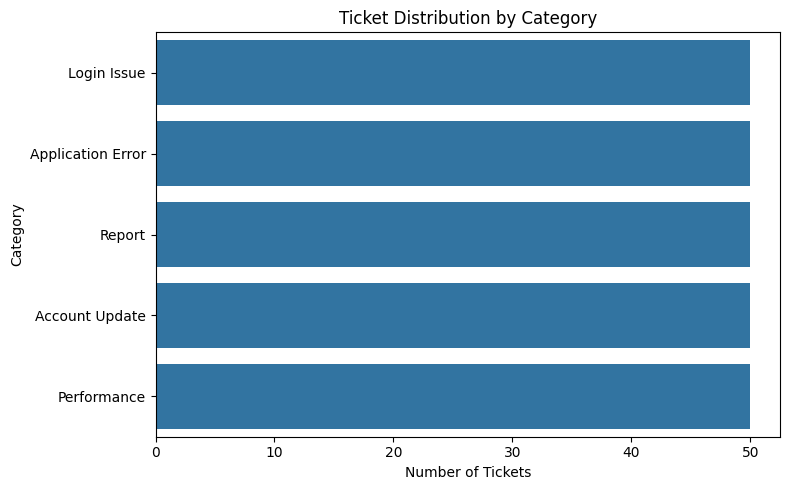

In [13]:
# Category Distribution — Chart 1

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)

plt.title("Ticket Distribution by Category")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [14]:
# Priority Analysis

priority_counts = df["priority"].value_counts()

print("Tickets by priority:")
print(priority_counts)

Tickets by priority:
priority
Medium      82
High        78
Critical    46
Low         44
Name: count, dtype: int64


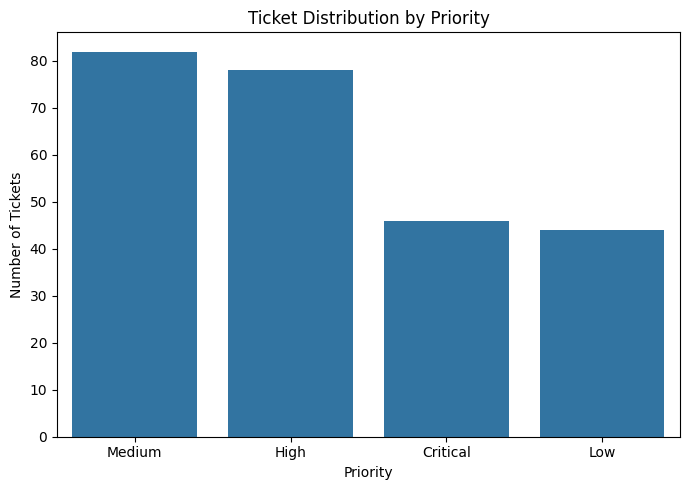

In [15]:
# Priority Distribution — Chart 2

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="priority",
    order=df["priority"].value_counts().index
)

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

## Key Observations

* **Dataset Size & Balance:** The synthetic dataset contains a high level of diversity in ticket descriptions. Since the dataset contains only 250 records, most descriptions occur only a few times, with no single description being excessively repeated. This provides varied textual examples across categories and helps reduce reliance on exact duplicate descriptions during model training, making the dataset suitable for basic NLP and text-classification experiments.
* **Priority Distribution:** Tickets span four priority levels (**Critical**, **High**, **Medium**, and **Low**), with **Medium** and **High** priorities forming the majority.
* **Status Variance:** Ticket status is distributed across **Open**, **Closed**, and **In Progress**, with the distribution varying based on ticket priority.
* **Category & Priority Matrix:** The *Priority × Category* analysis shows that all categories contain tickets across all priority levels, providing solid variety for analysis and model training.
* **Data Quality:** There are no missing values or duplicate records, so no additional data cleaning is required. NLP preprocessing of the ticket descriptions will be performed in train.ipynb as part of the machine learning pipeline.